In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score 

In [2]:
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', ' setting_2', 'setting_3']
sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',       
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' 
]
col_names = index_names + operational_settings + sensor_names
print(f"Column names defined. Total columns: {len(col_names)}")

Column names defined. Total columns: 26


In [7]:
train_df = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
train_df.columns = col_names

test_df = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None)
test_df.columns = col_names

rul_df = pd.read_csv("RUL_FD001.txt", header=None)
rul_df.columns = ["RUL"]

In [9]:
print(f'Training Data Shape: {train_df.shape}')
print(f'Training Data Shape: {test_df.shape}')
print(f'Training Data Shape: {rul_df.shape}')

print(f'Perceentage of Testing Data: {len(test_df)/(len(train_df)+len(test_df)):.2%}')

Training Data Shape: (20631, 26)
Training Data Shape: (13096, 26)
Training Data Shape: (100, 1)
Perceentage of Testing Data: 38.83%


In [12]:
print('-'*50 + '\nDataset Preview --> Training Data:\n')
display(train_df.head())
print('-'*50 + '\nDataset Preview --> Test Data:\n')
display(test_df.head())

--------------------------------------------------
Dataset Preview --> Training Data:



,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


--------------------------------------------------
Dataset Preview --> Test Data:



,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [14]:
print("Missing Values in Train:" , train_df.isnull().sum().sum())
print("Missin Values in Test:", test_df.isnull().sum().sum())

Missing Values in Train: 0
Missin Values in Test: 0


In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3    setting_2   20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR 

In [18]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


# Cleaning & Feature Engineering

## A. The Challenge of "Constant" Sensors
One of the first steps is removing sensors that provide no information (Constant Values).

- **Hypothesis:** A sensor with std = 0 is constant.
- **Reality Check:** In real-world sensor data, floating-point precision issues (Machine Epsilon) can cause a constant sensor to have a tiny standard deviation.
- **Technical Insight:**
Relying solely on std() == 0 failed to detect all constant sensors (like P2 and farB). Solution: We switched to counting unique values (nunique()). If a sensor has only 1 unique value, it is guaranteed to be constant, regardless of numerical noise.

## B. Target Engineering (RUL)
We calculate the Remaining Useful Life (RUL) and apply a cap (Clipping) at 125 cycles to model the healthy phase of the engine accurately.

In [22]:
# Handling constant (Dead sensors)
# Objecctive: Remove features tha carry no information (Variance = Information)

const_features = [col for col in train_df.columns 
                        if train_df[col].nunique()<=1]

print(f'Dead/Constant Sensors identified: {const_features}')

print('Number of Dead/Constant sensors: {len(const_features)} sensors.')

Dead/Constant Sensors identified: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Number of Dead/Constant sensors: {len(const_features)} sensors.


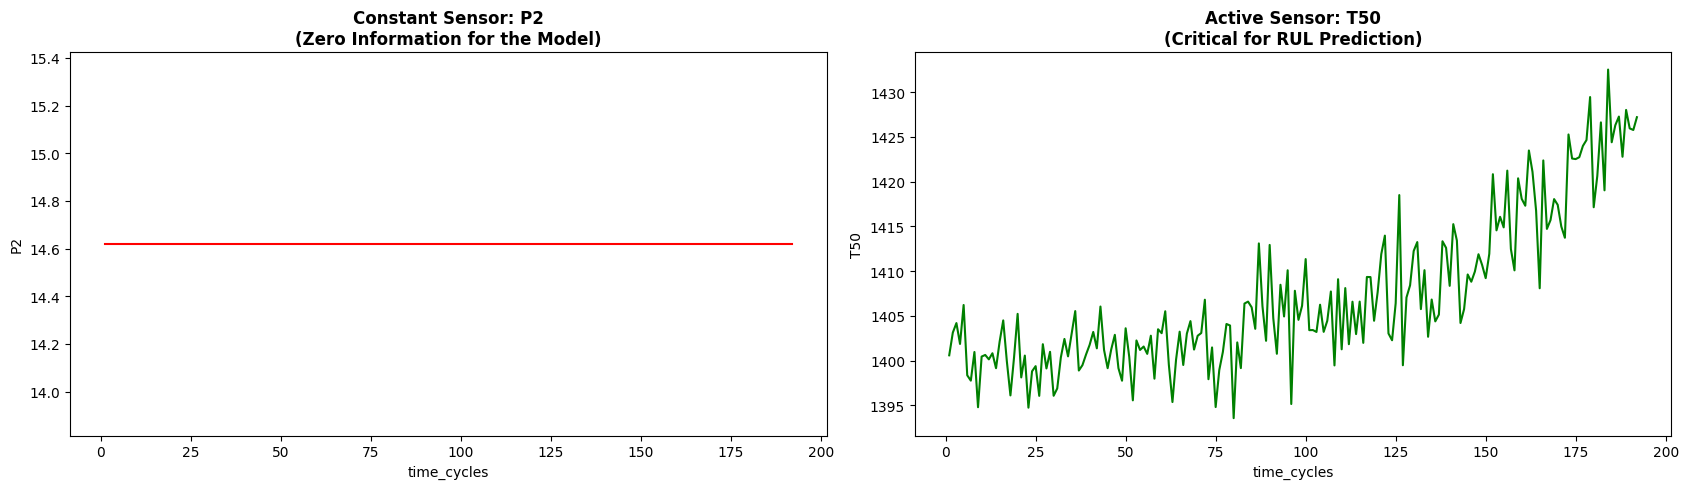

In [26]:
# Visual Validation(Proving the Point)
# Let's Plot 'P2' (which Method 1 Missed) vs 'T50' (Active)

dead_sensor = 'P2'
active_sensor = 'T50'

fig, ax = plt.subplots(1,2, figsize = (17,5))

# Plot Dead Sensor
sns.lineplot(x='time_cycles', y =dead_sensor, data = train_df[train_df['unit_number'] == 1],
            ax = ax[0], color = 'r')
ax[0].set_title(f'Constant Sensor: {dead_sensor}\n(Zero Information for the Model)',
                fontweight= 'bold')
#Plot active sensor
sns.lineplot(x='time_cycles', y = active_sensor, data= train_df[train_df['unit_number']==1],
             ax=ax[1], color='g'
)
ax[1].set_title(f'Active Sensor: {active_sensor}\n(Critical for RUL Prediction)', 
fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# drop these sensors (Dead Sensors) from training and test data
train_df.drop(columns=const_features, inplace=True)
test_df.drop(columns=const_features, inplace = True)

print('\nDropped constant columns Succesfully.')
print(f'New Training Shape: {train_df.shape}')
print(f'New Testing Shape: {test_df.shape}')


Dropped constant columns Succesfully.
New Training Shape: (20631, 19)
New Testing Shape: (13096, 19)


##  


Constructing the target (RUL) **The dataset provides the total life, but we need to predict the Remaining Useful Life**, At any given point.

In [29]:
def calculate_rul(data, unit_col='unit_number', cycle_col='time_cycles'):
    max_cycle = (
        data.groupby(unit_col)[cycle_col].max()
        .reset_index().rename(columns={cycle_col: 'max_of_unit'}))
    data = data.merge(max_cycle, on=unit_col, how='left')
    data['RUL'] = data['max_of_unit'] - data[cycle_col]
    data.drop('max_of_unit', axis=1, inplace=True)
    return data


train_df = calculate_rul(train_df)
train_df[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


   Piecewise Linear RUL (Clipping) Engines don't degrade linearly from Day 1.
   They operate normally (Healthy State) for a while, then degradation accelerates.
   **Technique: We clip the RUL at 125 cycles**.

   **Why?** This prevents the model from trying to predict "infinite health" in the
     early stages, focusing its attention on the critical degradation phase

In [30]:
RUL_THRESHOLD = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_THRESHOLD)
print(f"RUL Clipping applied. Max RUL is now capped at {RUL_THRESHOLD} cycles.")
print("\nRUL Statistics after Clipping:")

train_df['RUL'].describe().T

RUL Clipping applied. Max RUL is now capped at 125 cycles.

RUL Statistics after Clipping:


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

# Exploratory Data Analysis (EDA)
## A. Survival Analysis: How long do engines last?
   Before building predictive models, we need to establish a **baseline**

   - **Objective:** Understand the distribution of "Time-to-faliure".
   - **Why?** If most engines fail around 200 cycles, a model predicting 500 cycles is obviously wrong.
   

In [31]:
# Lifespan Statistics
engine_lifespan = train_df.groupby('unit_number')['time_cycles'].max()

print("Mean Lifespan:", engine_lifespan.mean())
print("Min Lifespan:", engine_lifespan.min())
print("Max Lifespan:", engine_lifespan.max())

Mean Lifespan: 206.31
Min Lifespan: 128
Max Lifespan: 362


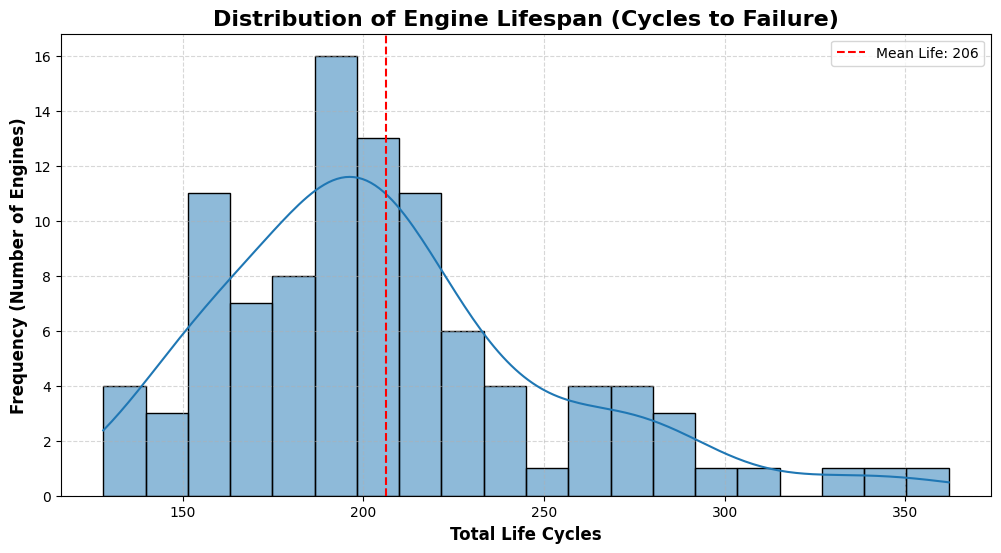

In [32]:
# Lifespan Distribution

# Histogram (Distribution)
plt.figure(figsize=(12, 6))
sns.histplot(engine_lifespan, kde=True, color='#1f77b4', bins=20)
plt.title('Distribution of Engine Lifespan (Cycles to Failure)', fontweight='bold', size=16)
plt.xlabel('Total Life Cycles', fontweight='bold', size=12)
plt.ylabel('Frequency (Number of Engines)', fontweight='bold', size=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(engine_lifespan.mean(), color='r', linestyle='--', label=f'Mean Life: {int(engine_lifespan.mean())}')
plt.legend()
plt.show()

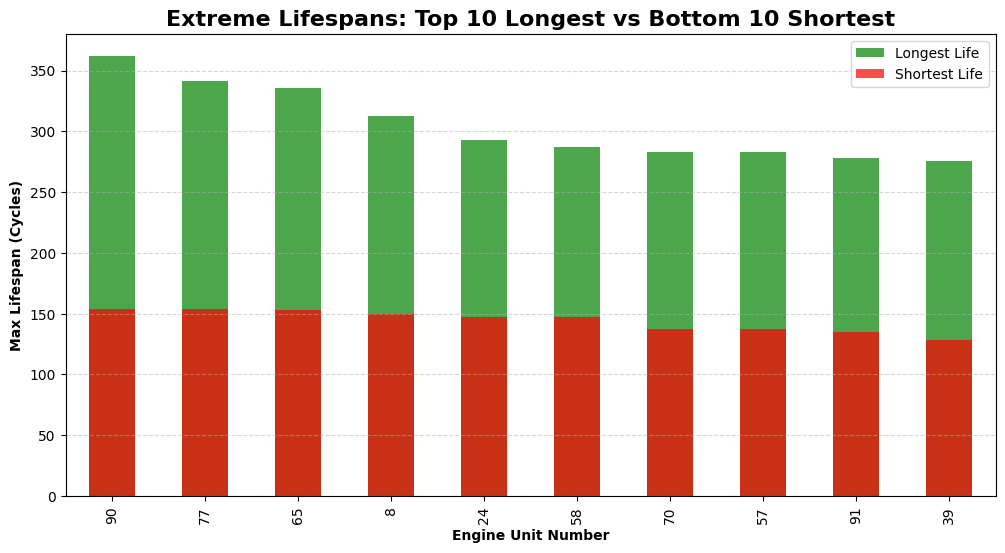

In [33]:
# Bar Chart (Extremes)
sorted_lifespan = engine_lifespan.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_lifespan.head(10).plot(kind='bar', color='green', alpha=0.7, label='Longest Life')
sorted_lifespan.tail(10).plot(kind='bar', color='red', alpha=0.7, label='Shortest Life')
plt.title('Extreme Lifespans: Top 10 Longest vs Bottom 10 Shortest', fontweight='bold', size=16)
plt.xlabel('Engine Unit Number', fontweight='bold')
plt.ylabel('Max Lifespan (Cycles)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

B. Sensor Degradation Analysis
Now we dig deeper into the physics of failure.
1. **Correlation:** Which sensors drift as RUL decreases?
2. **Signal Trajectory:** Visualizing the smoothed degradation path.
3. **Separability:** Can we easily distinguish "Healthy" vs "Failing" states?
4. **PCA Projection:** Compressing 14+ sensors into a 2D map to see the "Path to Failure".

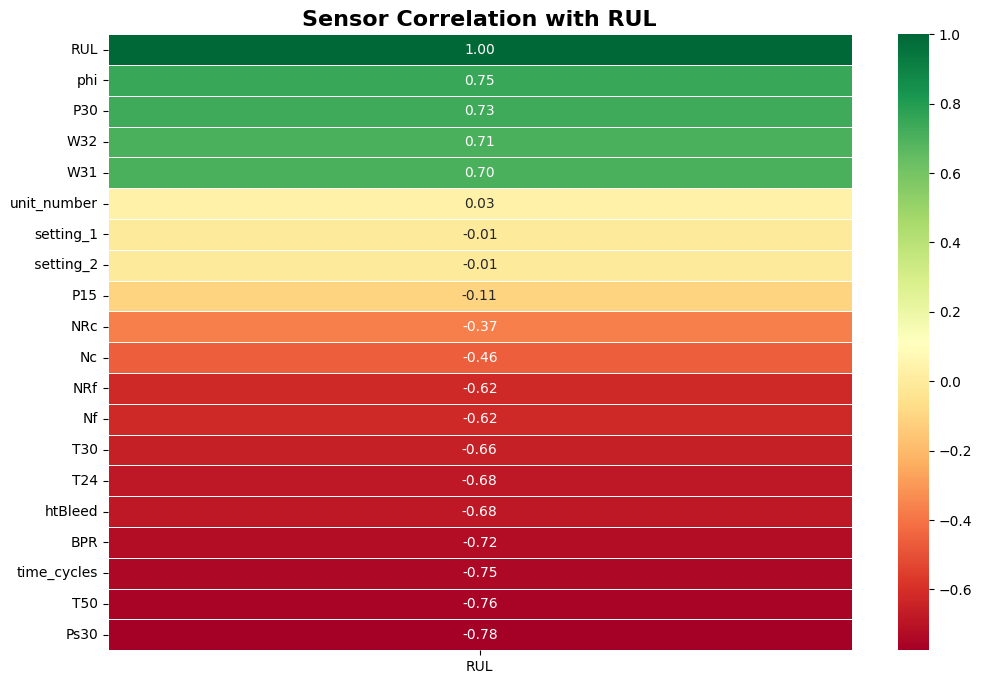

Insight: Sensors with high positive or negative correlation are the most important predictors.


In [39]:
# Correlation Heatmap

# Which sensors correlate most strongly with RUL?
corr_matrix = train_df.corr()
rul_corr = corr_matrix['RUL'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(12, 8))
sns.heatmap(rul_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Sensor Correlation with RUL', fontsize=16, fontweight='bold')
plt.show()

print('Insight: Sensors with high positive or negative correlation are the most important predictors.')

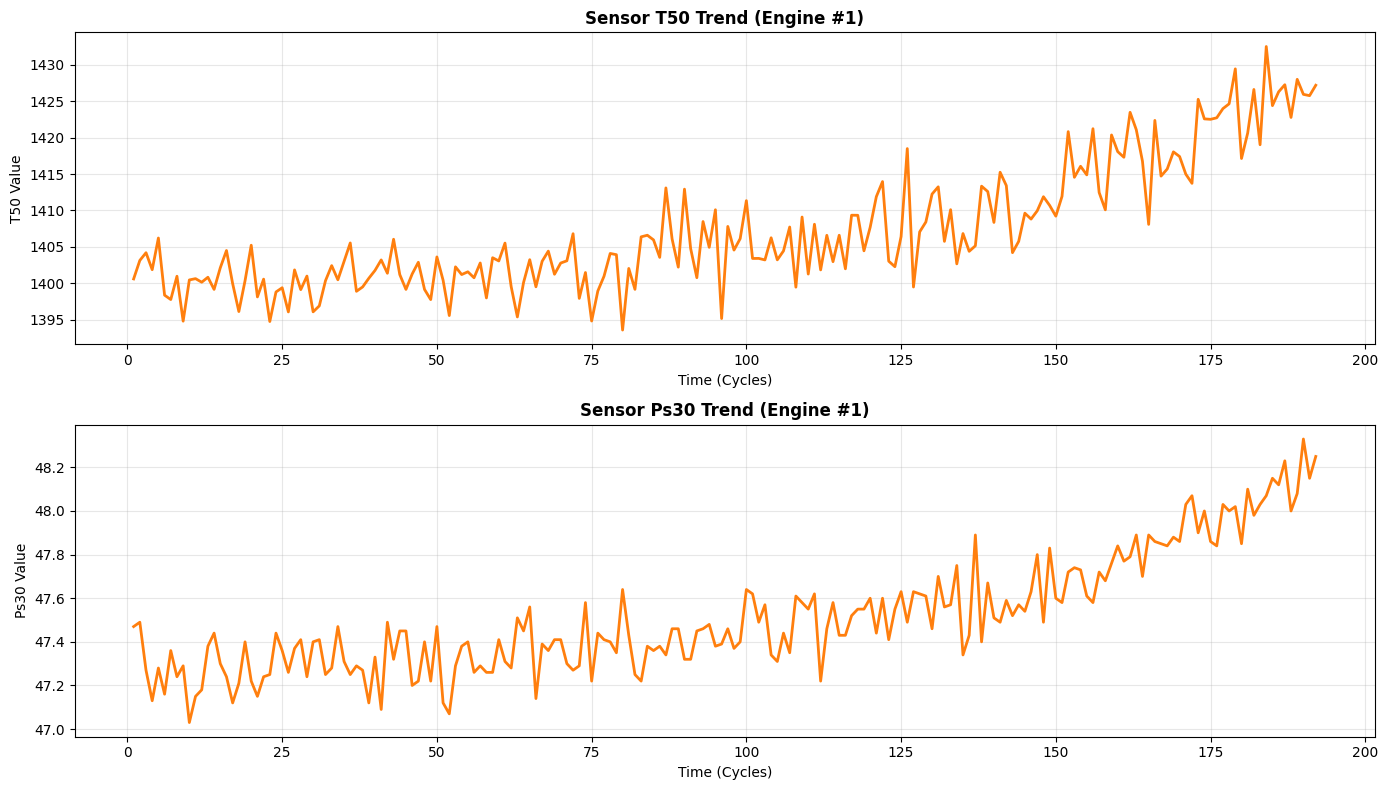

In [40]:
# Visualize key sensors identified by correlation

top_sensors = ['T50', 'Ps30']
sample_unit = 1

fig, ax = plt.subplots(len(top_sensors), 1, figsize=(14, 8))

for i, sensor in enumerate(top_sensors):
    unit_data = train_df[train_df['unit_number'] == sample_unit]
    ax[i].plot(unit_data['time_cycles'], unit_data[sensor], color='#ff7f0e', linewidth=2)
    ax[i].set_title(f'Sensor {sensor} Trend (Engine #{sample_unit})', fontsize=12, fontweight='bold')
    ax[i].set_ylabel(f'{sensor} Value', fontsize=10)
    ax[i].set_xlabel('Time (Cycles)')
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

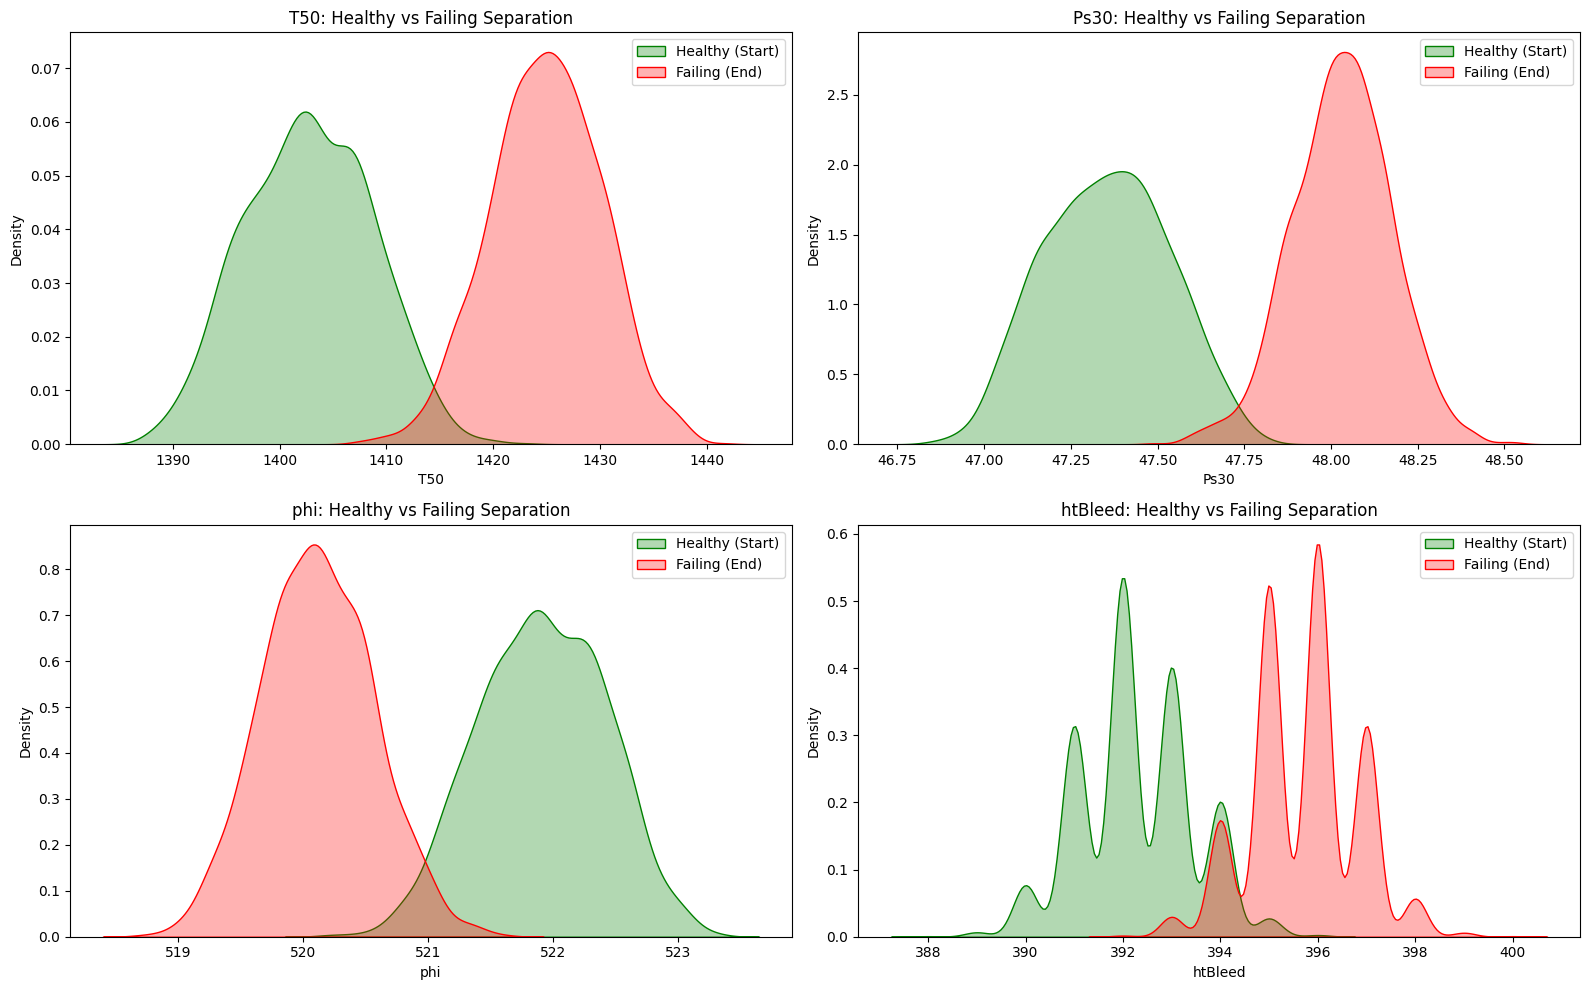

In [41]:
# Health State Separation (KDE Plot)
# Can we distinguish between a 'New' engine and a 'Dying' engine?

early_life = train_df[train_df['time_cycles'] < 20]# First 20 cycles
late_life = train_df[train_df['RUL'] < 20]# Last 20 cycles

sensors_to_compare = ['T50', 'Ps30', 'phi', 'htBleed']
available_sensors = [s for s in sensors_to_compare if s in train_df.columns]

if available_sensors:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    axes = axes.flatten()

    for i, sensor in enumerate(available_sensors):
        sns.kdeplot(early_life[sensor], fill=True, color="green", label='Healthy (Start)', ax=axes[i], alpha=0.3)
        sns.kdeplot(late_life[sensor], fill=True, color="red", label='Failing (End)', ax=axes[i], alpha=0.3)
        axes[i].set_title(f'{sensor}: Healthy vs Failing Separation')
        axes[i].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Selected sensors were dropped during cleaning.")

# Preprocessing & Modeling

Machine Learning models (like Linear Regression, SVR, and Neural Networks) are sensitive to the scale of input features.

- **The Problem:** Sensor T50 might range from 1000-2000, while Ps30 ranges from 10-20.        The model might biasedly think T50 is more important just because the numbers are bigger.
- **The Solution:** We apply MinMax Scaling to bring all features into the range.
.
- **Critical Rule:** We fit the scaler ONLY on the Training Data to prevent Data Leakage, then we apply that same scaler to the Test Data.

In [42]:
# Select features to scale
## We exclude 'unit_number', 'time_cycles', and 'RUL' because they are identifiers/targets, not sensor inputs.

features_to_normalize = [col for col in train_df.columns if col not in ['unit_number', 'time_cycles', 'RUL']]
scaler = MinMaxScaler()
train_df[features_to_normalize] = scaler.fit_transform(train_df[features_to_normalize])
test_df[features_to_normalize] = scaler.transform(test_df[features_to_normalize])


print("\nScaling completed successfully.")
print(f"Features Scaled: {len(features_to_normalize)}")

print("Data Scaling Completed (Range 0-1).")
print('-' * 30 + '\nData Preview after Scaling (Train) :\n')
display(train_df.head())

print('-' * 30 + '\nCheck Min/Max values (Should be 0 and 1) :\n')
display(train_df[features_to_normalize].describe().loc[['min', 'max']])


Scaling completed successfully.
Features Scaled: 17
Data Scaling Completed (Range 0-1).
------------------------------
Data Preview after Scaling (Train) :



,unit_number,time_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125


------------------------------
Check Min/Max values (Should be 0 and 1) :



,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


  Splitting Data for Evaluation
  In the C-MAPSS dataset challenge, the evaluation criteria is specific:

  - **Training:** We use the full history of the training units.
  - **Testing:** We are given partial history for test units, and we must predict the RUL at the very last recorded cycle.
     
Therefore, for the Test Set (X_test), we extract only the last row of data for each engine unit to compare it against the Ground Truth file (rul_df.txt).

In [44]:
# Prepare Training Data
X_train = train_df[features_to_normalize]
y_train = train_df['RUL']

# We need to predict RUL at the LAST observed time cycle for each unit in the test set.
X_test_last_cycle = test_df.groupby('unit_number').last().reset_index()
X_test = X_test_last_cycle[features_to_normalize]
y_true = rul_df['RUL'] # y_true: The actual Ground Truth RUL from the provided file

print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data:  X={X_test.shape},  y={y_true.shape}")

# Safety Check: Ensure we have one prediction target per test unit
assert X_test.shape[0] == y_true.shape[0], "Error: Mismatch in Test Data dimensions!"

Training Data: X=(20631, 17), y=(20631,)
Testing Data:  X=(100, 17),  y=(100,)


 ## Modeling & Benchmarking
 
 Now comes the core experimentation. We will train and evaluate four different algorithms   to find the best fit for our data.

 - **Strategy:** Start simple, then increase complexity.

 1.- **Linear Regression:** The baseline. If complex models don't beat this significantly,   they aren't worth the computational cost.
 
 2.- **SVR (Support Vector Regressor):** Good for high-dimensional spaces but can be slow.
 
 3.- **Random Forest:** An ensemble method that handles non-linearities well.
 
 4.- **XGBoost:** The state-of-the-art gradient boosting algorithm.
 
- **Metrics:**

   - **RMSE (Root Mean Squared Error):** The penalty is in "Cycles". (e.g., RMSE=20 means we are off by ~20 cycles on average).

In [45]:
# Container for collecting results
results_summary = []

def evaluate_model(model, X_train, y_train, X_test, y_true, model_name):
    """
    Standardized evaluation function:
    1. Fits the model
    2. Predicts on Test Data (Last Cycle)
    3. Calculates Metrics (RMSE, R2)
    4. Plots Actual vs Predicted RUL
    """
    model.fit(X_train, y_train)  # Train
    y_pred = model.predict(X_test)  # Predict

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Score
    r2 = r2_score(y_true, y_pred)

    # Log results
    results_summary.append({
        'Model': model_name,
        'RMSE': rmse,
        'R2 Score': r2
    })

    # Summary
    print(f"--- {model_name} Results ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.2%}")

    # Plot Predictions
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label='Actual RUL', linestyle='--')
    plt.plot(y_pred, label=f'Predicted ({model_name})')
    plt.xlabel('Test Units Index')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred

Training Linear Regression (Baseline)...
--- Linear Regression Results ---
RMSE: 21.90
R2:   72.22%


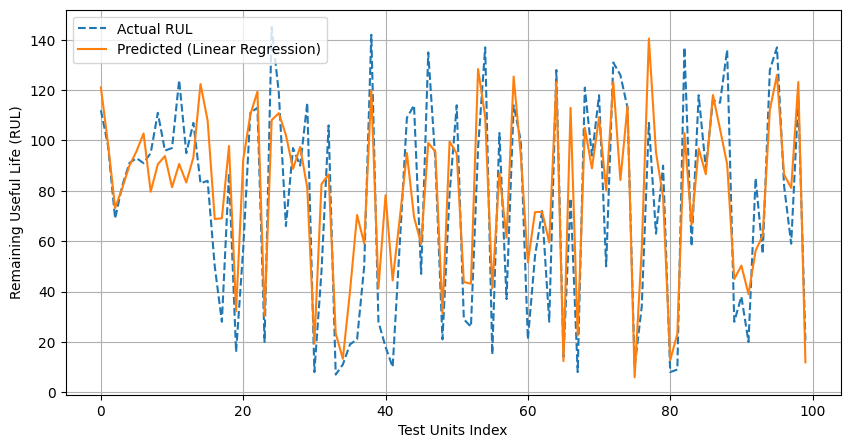

In [46]:
# Linear Regression (Baseline)

lr_model = LinearRegression()
print("Training Linear Regression (Baseline)...")
_ = evaluate_model(lr_model, X_train, y_train, X_test, y_true, "Linear Regression")

--- SVR Results ---
RMSE: 19.84
R2:   77.20%


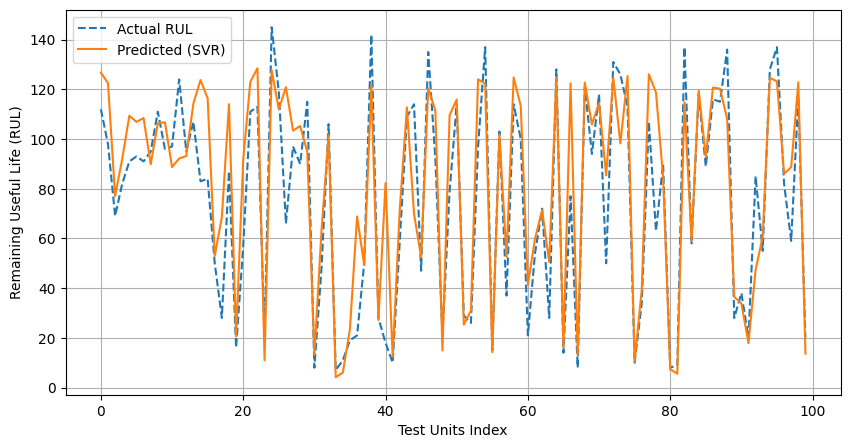

In [47]:
# Support Vector Regressor (SVR)

svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)  # Kernel='rbf' for non-linear relationships

_ = evaluate_model(svr_model, X_train, y_train, X_test, y_true, "SVR")

--- Random Forest Results ---
RMSE: 18.16
R2:   80.91%


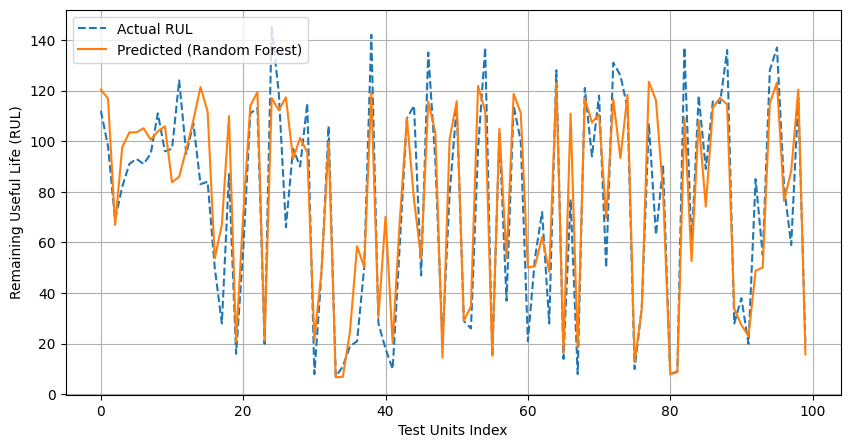

In [48]:
# Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

_ = evaluate_model(rf_model, X_train, y_train, X_test, y_true, "Random Forest")

--- XGBoost Results ---
RMSE: 17.69
R2:   81.87%


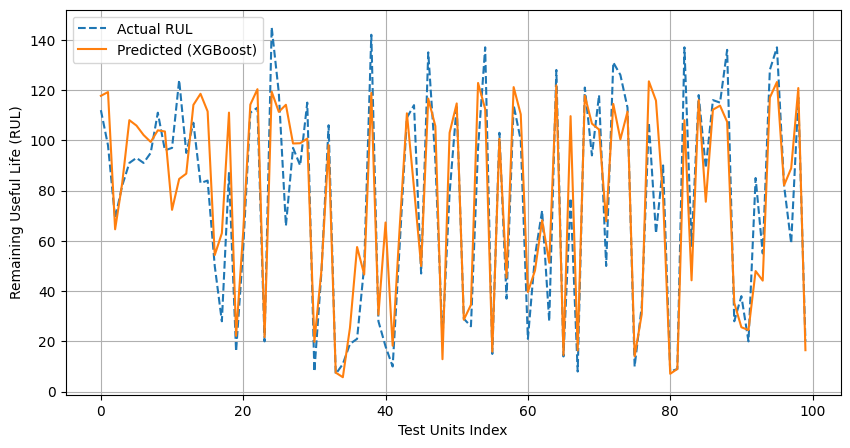

In [49]:
# XGBoost Regressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)

_ = evaluate_model(xgb_model, X_train, y_train, X_test, y_true, "XGBoost")


 FINAL MODEL COMPARISON 


,Model,RMSE,R2 Score
3,XGBoost,17.692938,0.818724
2,Random Forest,18.158424,0.809060
1,SVR,19.844600,0.771953
0,Linear Regression,21.904171,0.722160


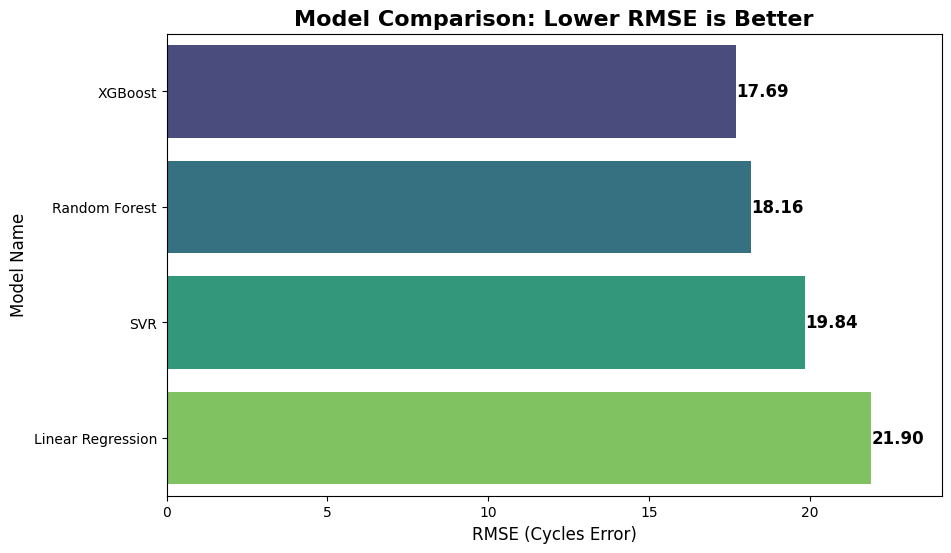

The Best Model is: XGBoost


In [59]:
# Compare Models

results_df = pd.DataFrame(results_summary).sort_values(by='RMSE')

print("\n FINAL MODEL COMPARISON ")
display(results_df.style.background_gradient(cmap='Greens_r', subset=['RMSE']))

# plot Leaderboard
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', hue= 'Model', data=results_df, palette='viridis',  legend = False)
plt.title('Model Comparison: Lower RMSE is Better', fontsize=16, fontweight='bold')
plt.xlabel('RMSE (Cycles Error)', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
# Add value labels
for index, value in enumerate(results_df['RMSE']):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=12, fontweight='bold')

plt.xlim(0, max(results_df['RMSE'])*1.1)
plt.show()

print(f"The Best Model is: {results_df.iloc[0]['Model']}")

In [70]:
# Save Artifacts for Production

best_model = xgb_model
joblib.dump(best_model, 'best_rul_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## Real-time Simulation (The "Digital Twin")
   Metrics like RMSE are abstract. To truly trust the model, we need to see it in action.     In this final step, we perform a **Trajectory Reconstruction:**

  1. Select a random engine from the Test Set (e.g., Unit #24).
  2. Feed its sensor data cycle-by-cycle into the model.
  3. Compare the **Predicted RUL** vs. **The Actual RUL** over time.
      
This visualization proves that the model isn't just guessing; it's tracking the degradation trend as it happens.

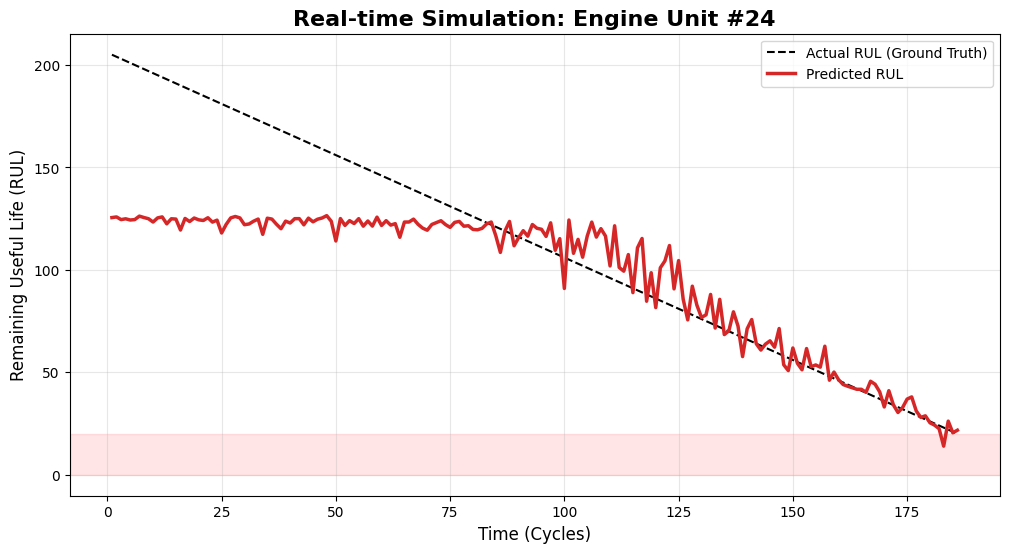

In [74]:
def simulate_engine_life(unit_id, model, scaler, data_test, true_rul_df):
    """
    Simulates the RUL prediction for a single engine unit over its entire history.
    Visualizes the 'Actual' vs 'Predicted' degradation path.
    """
    # Take the data for the specific unit
    # Note: data_test is ALREADY scaled
    engine_data = data_test[data_test['unit_number'] == unit_id].copy()
    # Extract features directly
    X_engine = engine_data[features_to_normalize]
    pred_rul = model.predict(X_engine) # Predict
    #Construct Ground Truth (Actual RUL) for visualization
    # We know the Final RUL from the file, so we back-calculate the path.
    final_true_rul = true_rul_df.iloc[unit_id - 1]['RUL']
    max_cycle = engine_data['time_cycles'].max()
    true_rul_series = []
    current_rul = final_true_rul + max_cycle
    for _ in range(len(engine_data)):
        current_rul -= 1
        true_rul_series.append(current_rul)

    plt.figure(figsize=(12, 6))
    plt.plot(engine_data['time_cycles'], true_rul_series, color='black', linestyle='--', label='Actual RUL (Ground Truth)')
    plt.plot(engine_data['time_cycles'], pred_rul, color='#d62728', linewidth=2.5, label='Predicted RUL')
    plt.title(f'Real-time Simulation: Engine Unit #{unit_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Time (Cycles)', fontsize=12)
    plt.ylabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Failure Zone')
    plt.show()


# Simulate Engine Unit #24
simulate_engine_life(24, best_model, scaler, test_df, rul_df)